In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("dataset1.csv")

df.head()

,idResource,idUser,chosenCategory,incentive
0,66445,311,5,EXTRINSIC
1,66445,671,5,EXTRINSIC
2,66445,672,5,EXTRINSIC
3,66446,672,5,EXTRINSIC
4,66446,311,5,EXTRINSIC


In [3]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(156398, 4)
<class 'pandas.DataFrame'>
RangeIndex: 156398 entries, 0 to 156397
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   idResource      156398 non-null  int64
 1   idUser          156398 non-null  int64
 2   chosenCategory  156398 non-null  int64
 3   incentive       156398 non-null  str  
dtypes: int64(3), str(1)
memory usage: 6.1 MB
None
idResource        0
idUser            0
chosenCategory    0
incentive         0
dtype: int64


In [4]:
df = df.dropna()  # or use fillna if needed

In [6]:
df[column] = df[column].astype(str)

In [9]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [11]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print(confusion_matrix(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 0.9925191815856778
[[28923   108]
 [  126  2123]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     29031
           1       0.95      0.94      0.95      2249

    accuracy                           0.99     31280
   macro avg       0.97      0.97      0.97     31280
weighted avg       0.99      0.99      0.99     31280



In [12]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.9928708439897698
[[28932    99]
 [  124  2125]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     29031
           1       0.96      0.94      0.95      2249

    accuracy                           0.99     31280
   macro avg       0.98      0.97      0.97     31280
weighted avg       0.99      0.99      0.99     31280



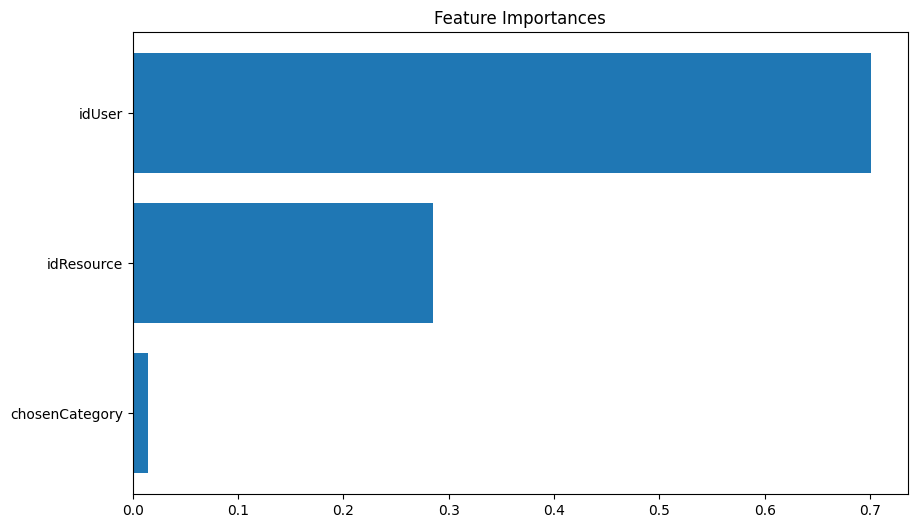

In [13]:
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
features = X.columns

indices = np.argsort(importances)

plt.figure(figsize=(10,6))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.show()